<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

data = pd.read_csv('/content/cybersecurity.csv')
data.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [ ]:
# Drop irrelevant columns and the redundant 'attack_type' column
data = data.drop(columns=['timestamp', 'src_ip', 'dst_ip', 'user_agent', 'url', 'attack_type'])

# Convert 'protocol' to one-hot encoding
data = pd.get_dummies(data, columns=['protocol'], drop_first=True)

# Define features (X) and target (y)
X = data.drop('label', axis=1)
y = data['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and apply StandardScaler to numerical features
scaler = StandardScaler()

# Identify numerical columns for scaling (excluding one-hot encoded 'protocol' columns and boolean 'is_internal_traffic')
numerical_cols = ['src_port', 'dst_port', 'bytes_sent', 'bytes_received']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data preprocessing complete. Shapes of training and testing sets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Data preprocessing complete. Shapes of training and testing sets:
X_train: (7000, 7), y_train: (7000,)
X_test: (3000, 7), y_test: (3000,)


### SVM Model Training and Evaluation

Now, we will train a Support Vector Machine (SVM) model on the preprocessed data. We'll use `GridSearchCV` to find the best hyperparameters for the SVM to optimize its performance. After training, we will evaluate the model using a classification report, confusion matrix, and accuracy score.

In [ ]:
# Define the parameter grid for GridSearchCV
param_grid = {'C': [0.1, 1, 10],
              'gamma': [0.1, 0.01, 0.001],
              'kernel': ['rbf']}

# Initialize GridSearchCV with SVC and the parameter grid
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3)

# Fit GridSearchCV to the training data
grid.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print("\nBest parameters found:", grid.best_params_)

# Get the best estimator (model) from GridSearchCV
best_svm_model = grid.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_svm_model.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.4s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.4s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.5s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.5s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.9s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.8s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.4s
[CV] END .........................C=1, gamma=0.1,

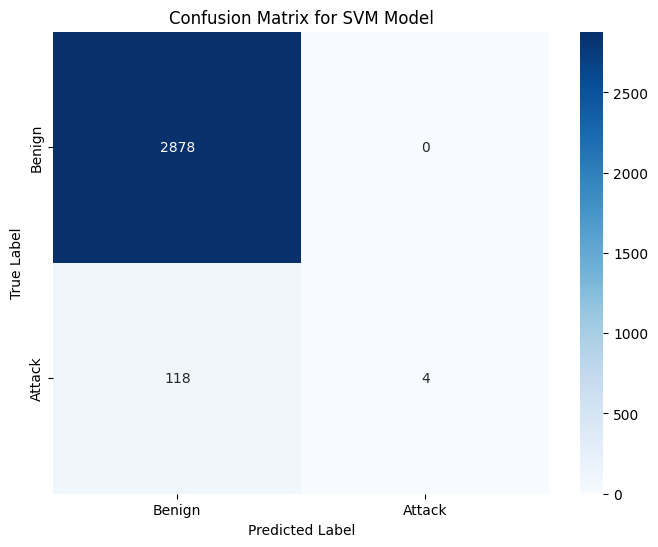

In [ ]:
# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()